# Serie A 2024-25 — Recent Form Analysis
**Author:** orbitalml  
**Dataset:** football-data.co.uk — I1.csv  
**Season:** 2024-25 — Last 5 matchdays

## 1. Setup and data loading

In [2]:
import pandas as pd

serie_A_24_25 = pd.read_csv("I1.csv")
cols = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG']
df = serie_A_24_25[cols]

## 2. Recent form calculation
Points system: Win = 3, Draw = 1, Loss = 0

In [91]:
teams = df.HomeTeam.unique()
n_teams = len(teams)
championship_matchdays = (n_teams-1) * 2
df=df.loc[(championship_matchdays-5)*(n_teams/2):,:]
home_wins = df[df.FTR == 'H'].groupby('HomeTeam')['FTR'].count().reindex(teams, fill_value=0)
away_wins = df[df.FTR == 'A'].groupby('AwayTeam')['FTR'].count().reindex(teams, fill_value=0)
draws = (df[df.FTR == 'D'].groupby('HomeTeam')['FTR'].count().reindex(teams, fill_value=0)) + (df[df.FTR == 'D'].groupby('AwayTeam')['FTR'].count().reindex(teams, fill_value=0))
recent_form = (home_wins*3 + away_wins*3 + draws).sort_values(ascending=False)



## 3. Standings — last 5 matchdays

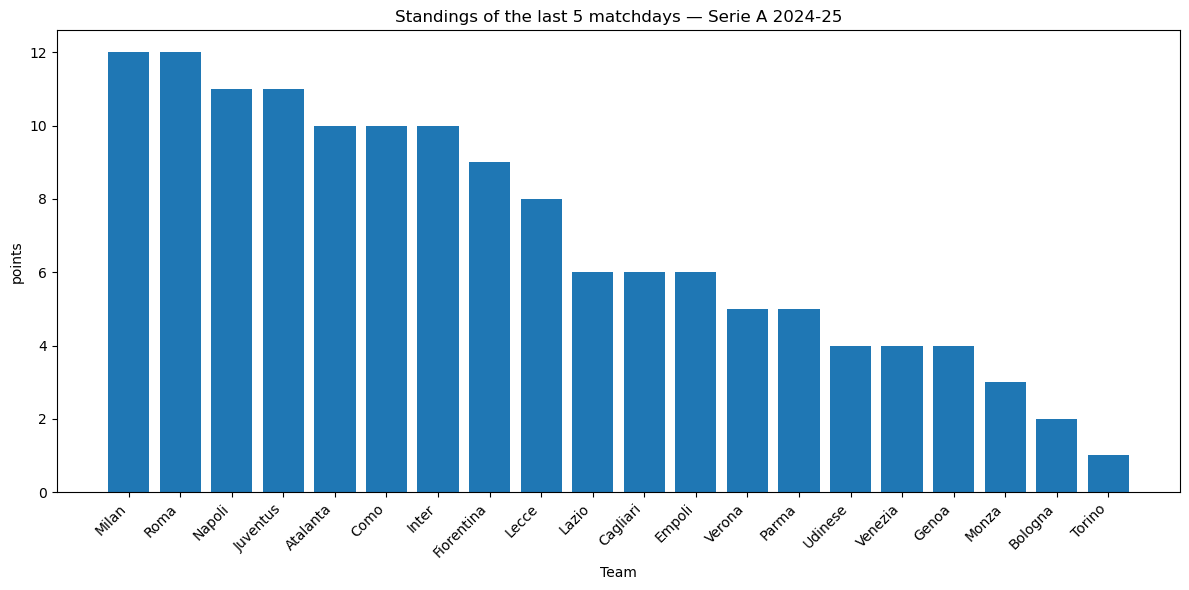

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(recent_form.index, recent_form.values)
plt.title("Standings of the last 5 matchdays — Serie A 2024-25")
plt.xlabel("Team")
plt.ylabel("points")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("standings_last_5_matchdays.png")
plt.show()